### THINGS object property relations analysis

In [3]:
import os
import pandas as pd
import scipy.io as scio
from os.path import join as pjoin

basedir = r'D:\visual_project\THINGS_project'
outdir = pjoin(basedir, r'animacy_analysis\derivatives\obj_pro_analysis')

def load_object_property(
        obj_tsv=pjoin(basedir, r'THINGS_stimuli\THINGSplus\Metadata\Concept-specific',
                      f'objectProperties_meanRatings.tsv'),
        size_tsv=pjoin(basedir, r'THINGS_stimuli\THINGSplus\Metadata\Concept-specific',
                       f'size_meanRatings.tsv')
):
    obj_df = pd.read_csv(obj_tsv, sep='\t')[
        ['uniqueID', 'manmade_mean', 'precious_mean', 'lives_mean', 'heavy_mean', 'natural_mean', 'moves_mean',
         'grasp_mean', 'hold_mean', 'be.moved_mean', 'pleasant_mean', 'deprecatedArousing_mean']]
    # 11 object properties
    obj_df = obj_df.rename(
        columns={'manmade_mean': 'manmade', 'precious_mean': 'precious', 'lives_mean': 'animacy', 'heavy_mean': 'heavy',
                 'natural_mean': 'natural', 'moves_mean': 'moves', 'grasp_mean': 'grasp', 'hold_mean': 'hold',
                 'be.moved_mean': 'be_moved', 'pleasant_mean': 'pleasant',
                 'deprecatedArousing_mean': 'deprecatedArousing'})
    obj_df.head()
    # size dimension
    size_df = pd.read_csv(size_tsv, sep='\t')[['uniqueID', 'Size_mean']]
    size_df = size_df.rename(columns={'Size_mean': 'size'})
    size_df['uniqueID'] = size_df.uniqueID.str.replace(' ', '_')

    obj12_df = pd.merge(
        left=obj_df, right=size_df, on='uniqueID', how='outer',
    ) # 12 object properties
    assert obj12_df.shape[0] == obj_df.shape[0] == size_df.shape[0]
#     obj12_df.head()
    return obj12_df

# load object properties ratings for entire THINGS object concept database
obj12_df = load_object_property() # (1854,13)
print(obj12_df.head())
# obj12_df.sort_values(by=['animacy'],ascending=False, inplace=False) # sorted by animacy, animate to inanimate
# print(obj_sort.head())
# print('max 10 animate images\n',obj12_df.uniqueID[:10])
# print('min 10 animate images\n',obj12_df.uniqueID[-10:])


          uniqueID  manmade  precious  animacy   heavy  natural   moves  \
0         aardvark   1.2632    4.6053   6.8421  4.7895   6.7105  6.9211   
1           abacus   6.8718    4.1026   1.5128  3.3590   2.2051  4.2308   
2        accordion   6.7500    4.5000   1.5000  5.0556   2.0000  4.6944   
3            acorn   1.2000    4.2000   5.0000  1.4857   6.8286  2.7143   
4  air_conditioner   6.8158    4.1579   1.2895  6.1842   1.3684  2.1842   

    grasp    hold  be_moved  pleasant  deprecatedArousing        size  
0  3.1579  3.1842    3.3158    4.3947              4.1579  273.743243  
1  5.5128  5.4359    5.6667    4.7436              3.7692  241.705882  
2  4.8889  4.9167    5.0833    5.0556              3.8889  260.434783  
3  6.5714  6.7429    6.7429    5.1143              3.5429  148.326087  
4  3.3947  2.6316    2.6842    5.7368              2.7632  281.923913  


In [4]:
# property RDM sorted by each property

import torch
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting

# plot rdm
def rdm_plot(outdir, matrix, name):
    fig = plt.figure()
    # Mask out the major diagonal
    plotting.plot_matrix(matrix,
                         colorbar=True,
    #                      vmax=0.8, vmin=-0.8
                         figure = fig)
#     plotting.show()
    fig.savefig(pjoin(outdir, f'rdm_pro_{name}_sorted.png'))
    
# standardize regressors
pro_nm = ['manmade', 'precious', 'animacy', 'heavy', 'natural', 'moves',
           'grasp', 'hold','be_moved', 'pleasant', 'deprecatedArousing', 'size']
for regname in pro_nm:
    obj12_df[regname] -= obj12_df[regname].mean()
    obj12_df[regname] /= obj12_df[regname].std()
X = obj12_df.to_numpy() # standaradize
ind = [y for y in range(1, 13)]
tmp_ = X[:,ind]
tmp = tmp_.tolist()
obj_pro = np.array(tmp)
print('object feature dimension: ', obj_pro.shape) # (1854,12)

# for ii in range(0,12):
#     obj_pro_ = obj_pro[np.argsort(-obj_pro[:,ii])] # 降序排列，从大到小
#     obj_pro_ = torch.tensor(obj_pro_)
#     rdm_obj_pro = 1-torch.corrcoef(obj_pro_).numpy() # shape(1854,1854)
# #     scio.savemat(pjoin(outdir, f'rdm_obj_pro_{pro_nm[ii]}_sorted.mat'), {'rdm_obj_pro':rdm_obj_pro})
#     print('obj pro RDM sorted by %s is:' %pro_nm[ii], rdm_obj_pro.shape)
#     rdm_plot(outdir,rdm_obj_pro,pro_nm[ii])

object feature dimension:  (1854, 12)


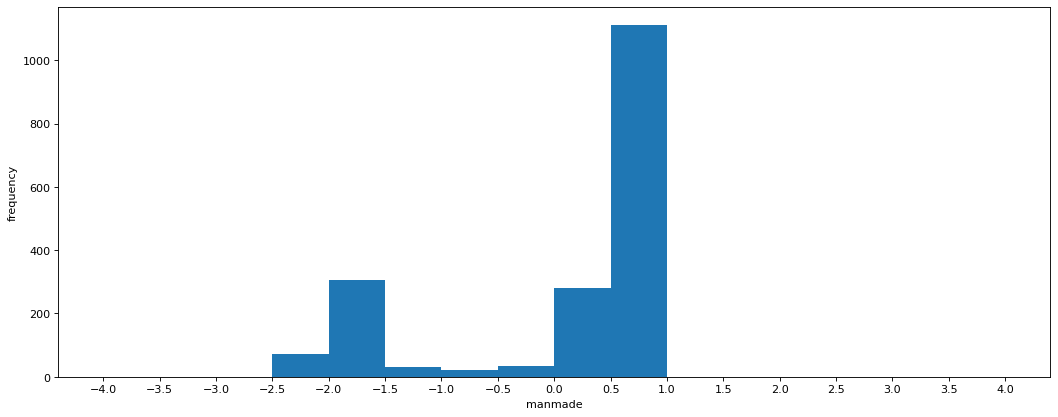

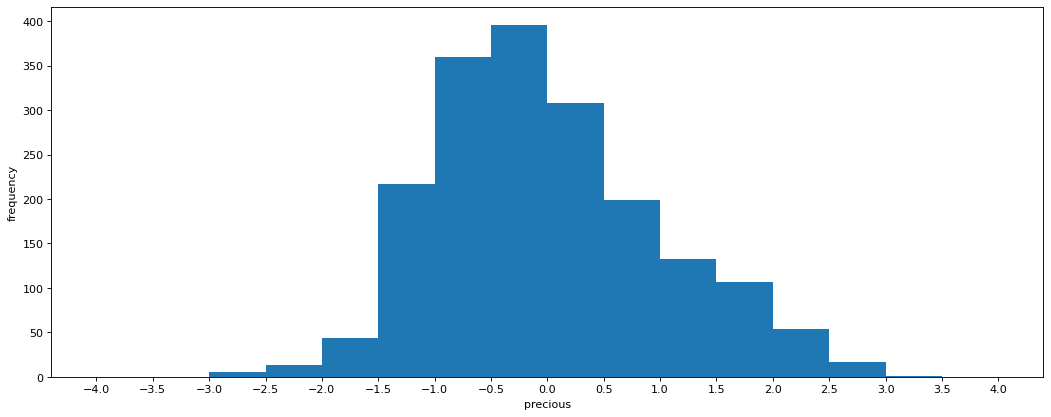

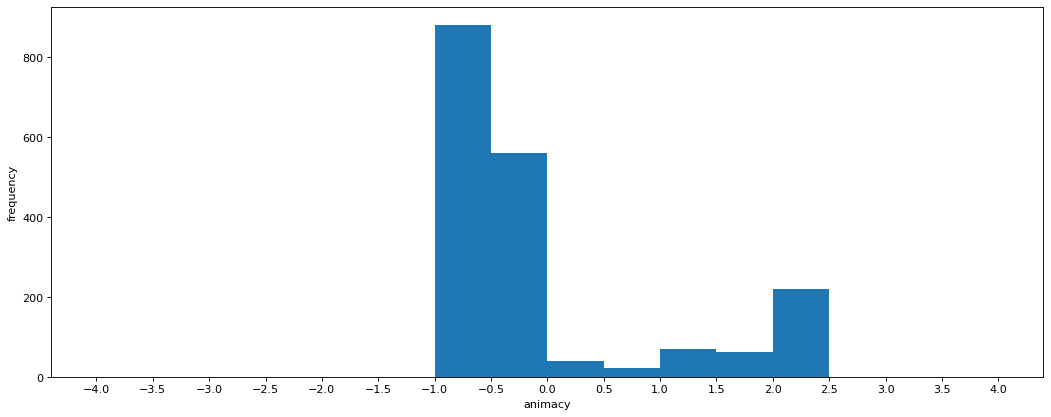

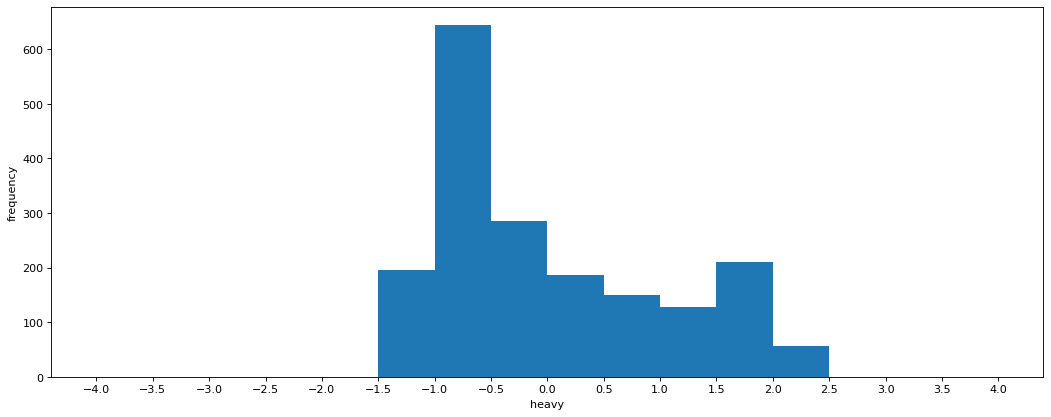

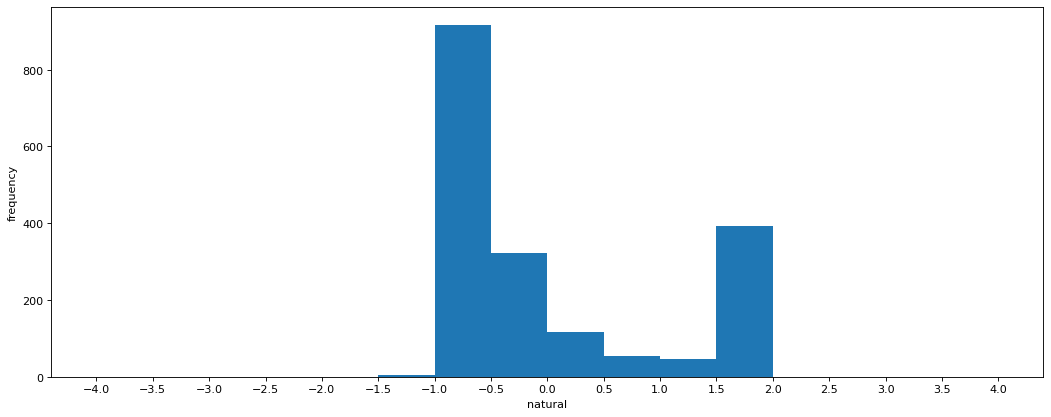

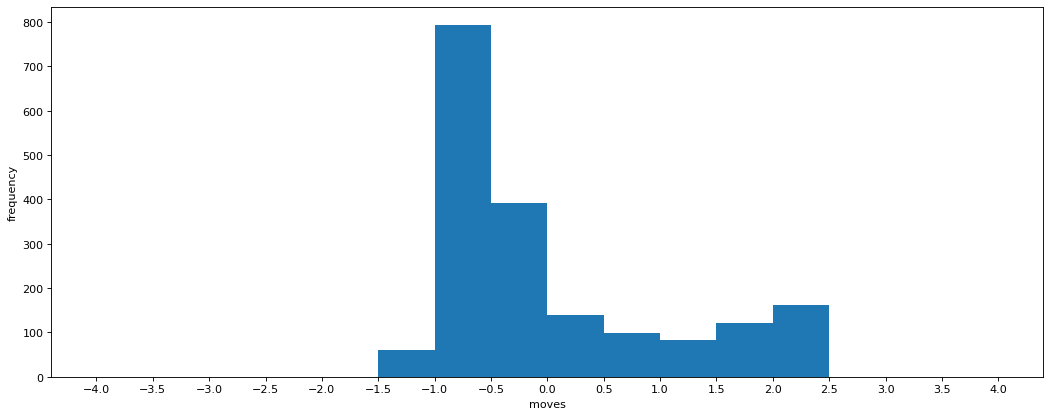

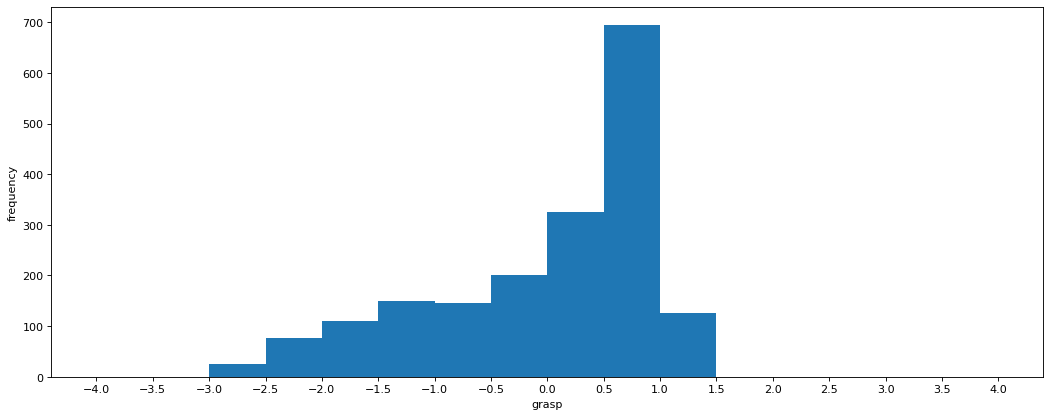

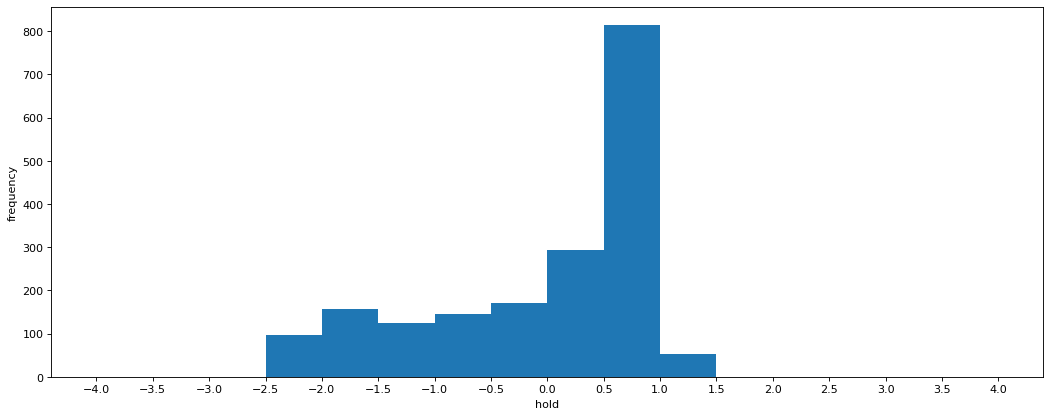

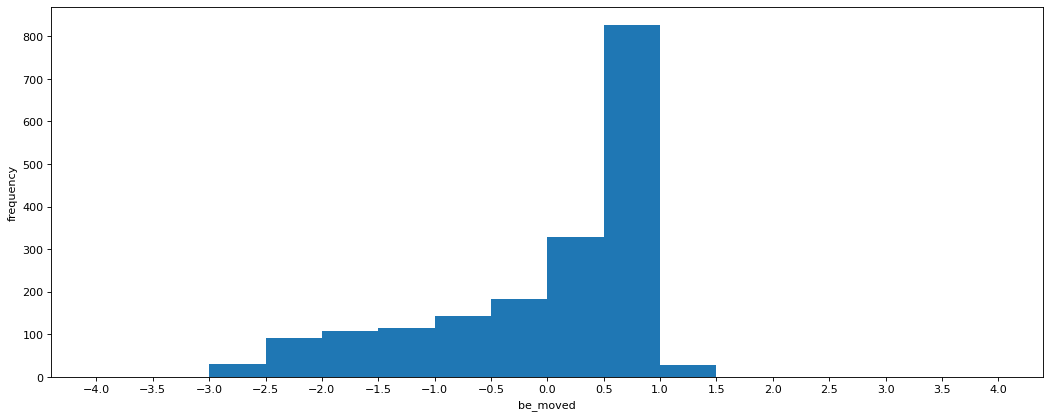

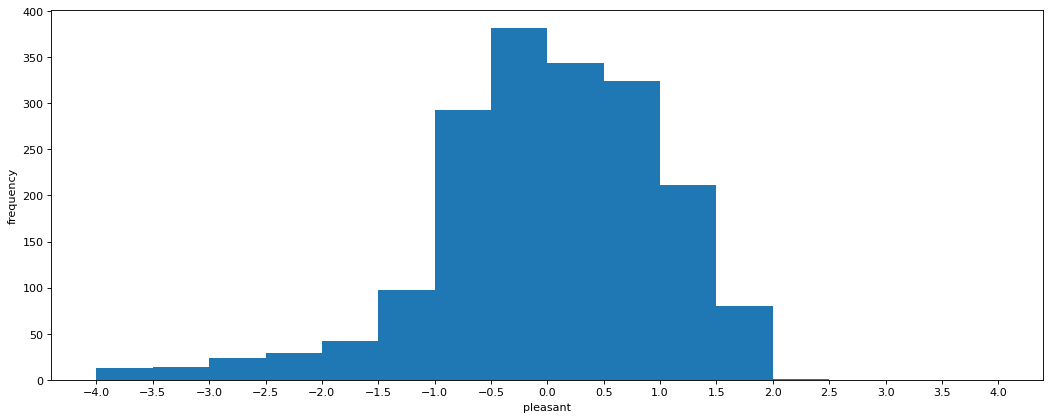

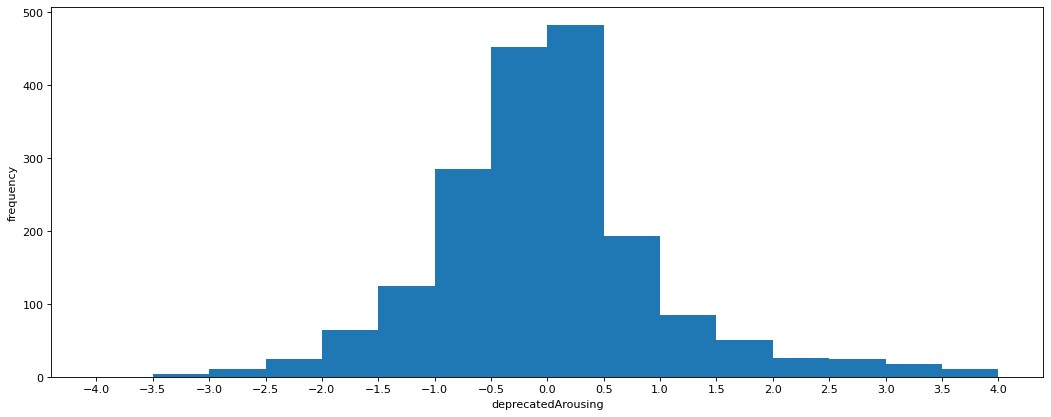

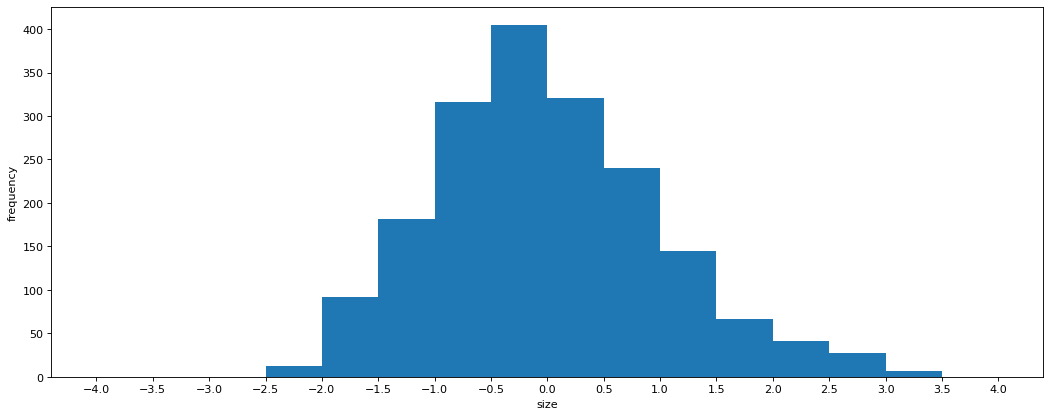

In [17]:
#属性分布直方图

d = 0.5
#组数
# np.max(obj_pro)=4.5, np.min(obj_pro)=-4
num_bin = np.arange(-4,4.5,d)
#print(max(a)-min(a),max(a),min(a))
for i in range(12):
    plt.figure(figsize=(16,6),dpi=80)

    plt.hist(obj_pro[:,i], num_bin)
    plt.xticks(num_bin)
    plt.xlabel(pro_nm[i])
    plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
    plt.show()


(12, 12)


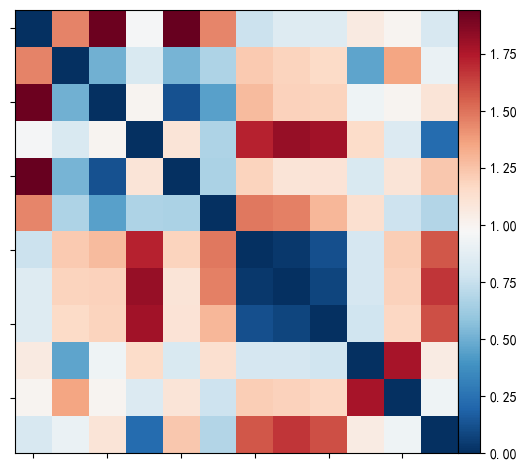

C:\Users\QDZHAO\AppData\Local\Temp\ipykernel_18016\2270726361.py:50: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(data, method='average',metric='euclidean')


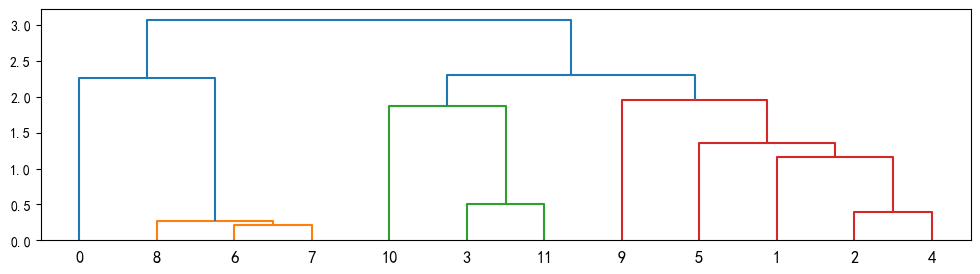

In [99]:
# hierarchical clustering to property RDM

import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from matplotlib import pyplot as plt

#1 to (1854,12)
# obj_pro_ = torch.tensor(obj_pro)
# rdm_obj_pro = 1-torch.corrcoef(obj_pro_).numpy()
# data = rdm_obj_pro # (1854,1854)
# fig = plt.figure()
# # Mask out the major diagonal
# plotting.plot_matrix(data, 
#                     colorbar=True,
# #                   vmax=0.8, vmin=-0.8
#                     figure = fig)
# plotting.show()
# # 1. 层次聚类
# # linkage方法用于计算两个聚类簇s和t之间的距离d(s,t)
# # 层次聚类编码为一个linkage矩阵。
# Z = linkage(data, method='average',metric='euclidean')
# # print("聚类过程：", Z)

# # 从给定链接矩阵定义的层次聚类中形成平面聚类。
# # distance：以距离为划分距离的准则
# f = fcluster(Z, t=25, criterion='distance',)
# # print("平面聚类结果：", f) # f lable与t的选择有关,大小为(1854,)

# fig = plt.figure(figsize=(12, 3))
# # 将层级聚类结果以树状图表示出来
# dn = dendrogram(Z)
# plt.xticks([])
# plt.show()

#2 to (12,1854)
obj_pro_s = torch.tensor(np.transpose(obj_pro))
rdm_obj_pro_s = 1-torch.corrcoef(obj_pro_s).numpy()
data = rdm_obj_pro_s # (12,12)
print(data.shape)
fig = plt.figure()
# Mask out the major diagonal
plotting.plot_matrix(data, 
                    colorbar=True,
#                   vmax=0.8, vmin=-0.8
                    figure = fig)
plotting.show()
# 1. 层次聚类
# linkage方法用于计算两个聚类簇s和t之间的距离d(s,t)
# 层次聚类编码为一个linkage矩阵。
Z = linkage(data, method='average',metric='euclidean')
# print("聚类过程：", Z)

# 从给定链接矩阵定义的层次聚类中形成平面聚类。
# distance：以距离为划分距离的准则
f = fcluster(Z, t=0.01, criterion='distance',)
# print("平面聚类结果：", f) # f lable与t的选择有关,大小为(1854,)
fig = plt.figure(figsize=(12, 3))
# 将层级聚类结果以树状图表示出来
dn = dendrogram(Z)
# plt.xlabel(np.array(pro_nm)[f-1].tolist())

plt.show()
# 存在问题，像natural和manmade非常负相关，但根据距离度量二者相距很远，所以考虑取绝对值再进行分析。
# 故这里不再考虑对原始RDM矩阵分析

In [107]:
print(pro_nm)

['manmade', 'precious', 'animacy', 'heavy', 'natural', 'moves', 'grasp', 'hold', 'be_moved', 'pleasant', 'deprecatedArousing', 'size']


(12, 1854)
(12, 12)


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0, 0.5, 'be_moved'),
  Text(0, 1.5, 'grasp'),
  Text(0, 2.5, 'hold'),
  Text(0, 3.5, 'heavy'),
  Text(0, 4.5, 'size'),
  Text(0, 5.5, 'precious'),
  Text(0, 6.5, 'pleasant'),
  Text(0, 7.5, 'Arousing'),
  Text(0, 8.5, 'moves'),
  Text(0, 9.5, 'natural'),
  Text(0, 10.5, 'manmade'),
  Text(0, 11.5, 'animacy')])

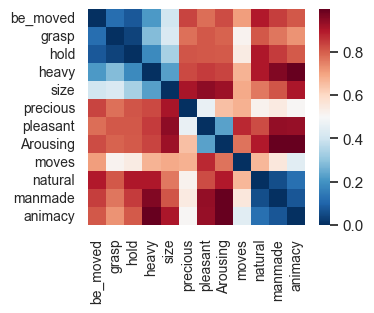

In [40]:
# sorting RDM12x12 according to clustering result
# obj_pro_s = torch.tensor(np.transpose(obj_pro))
# rsm_obj_pro_s = torch.corrcoef(obj_pro_s).numpy()
# data = 1-np.maximum(rsm_obj_pro_s,-rsm_obj_pro_s) # (12,12)
# print(data.shape)  # 对相似性矩阵取绝对值，再计算RDM，取值范围(0,1)
# fig = plt.figure()
# # Mask out the major diagonal
# plotting.plot_matrix(data, 
#                     colorbar=True,
#                     labels=pro_nm,
# #                   vmax=0.8, vmin=-0.8
#                     figure = fig)
# plotting.show()

# # 1. 层次聚类
# # linkage方法用于计算两个聚类簇s和t之间的距离d(s,t)
# # 层次聚类编码为一个linkage矩阵。
# Z = linkage(data, method='average',metric='euclidean')
# # print("聚类过程：", Z)

# # 从给定链接矩阵定义的层次聚类中形成平面聚类。
# # distance：以距离为划分距离的准则
# f = fcluster(Z, t=0.75, criterion='distance',)
# # print("平面聚类结果：", f) # f lable与t的选择有关,大小为(1854,)
# fig = plt.figure(figsize=(12, 3))
# # 将层级聚类结果以树状图表示出来
# dn = dendrogram(Z)
# plt.show()

# 按照聚类结果对RDM矩阵重排
pro_nm = ['manmade', 'precious', 'animacy', 'heavy', 'natural', 'moves',
           'grasp', 'hold','be_moved', 'pleasant', 'Arousing', 'size']
sort = [8,6,7,3,11,1,9,10,5,4,0,2]
obj_pro_sort = np.transpose(obj_pro)[sort]
print(obj_pro_sort.shape)
obj_pro_s = torch.tensor(obj_pro_sort)
rsm_obj_pro_s = torch.corrcoef(obj_pro_s).numpy()
data = 1-np.maximum(rsm_obj_pro_s,-rsm_obj_pro_s) # (12,12)
print(data.shape)

from matplotlib import font_manager as fm

# fig = plt.figure(figsize=(2.5,2.5))

# # Mask out the major diagonal
# plotting.plot_matrix(data,
#                      colorbar=True,
#                      labels=np.array(pro_nm)[sort].tolist(),
# #                   vmax=0.8, vmin=-0.8
#                      figure = fig)
# plotting.show()
#
pd_data=pd.DataFrame(data,index=np.array(pro_nm)[sort].tolist(),columns=np.array(pro_nm)[sort].tolist())
rc = {'font.sans-serif': ['Arial']}

plt.figure(figsize=(3.5,2.8))
sns.set(rc = rc)
sns.heatmap(pd_data,cmap='RdBu_r')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# f_4 = fcluster(Z, t=0.75, criterion='distance',)# 在pca降维后平面上给散点图赋予两类或四类颜色

(1854, 12)
explained variance: [4.66388821 3.34873158 1.91008646 0.71939941 0.41125088 0.36198733
 0.19969768 0.16316735 0.10372717 0.06201474 0.03646947 0.01957973]
explained variance ratio: [0.38865735 0.27906096 0.15917387 0.05994995 0.03427091 0.03016561
 0.01664147 0.01359728 0.00864393 0.0051679  0.00303912 0.00163164]


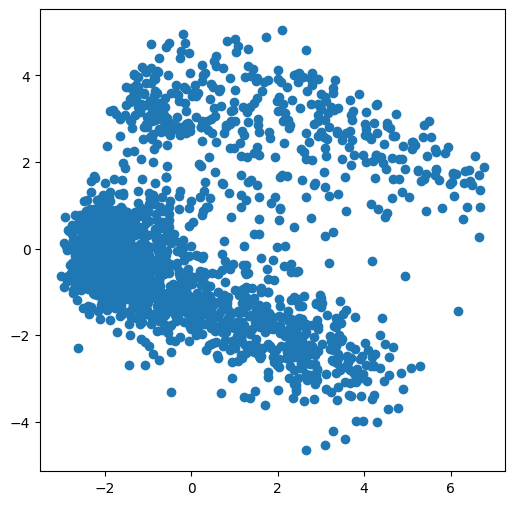

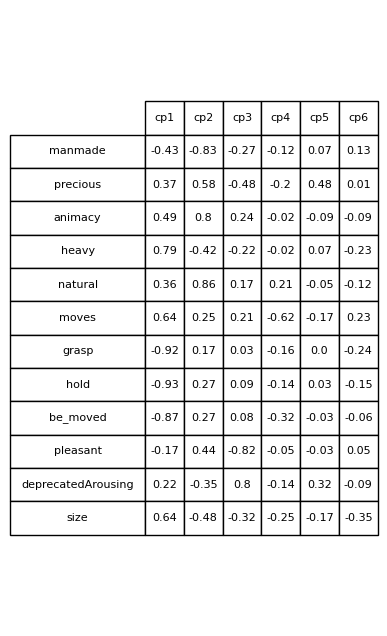

In [8]:
# 以属性为特征，PCA提取属性主成分
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print(obj_pro.shape) #(1854，12)

# 1 apply PCA
# 1.1 apply PCA to obj_pro (1854,12)
pca = PCA(n_components=12)
pca.fit(obj_pro) # property as feature(1854,12)
obj_pro_pcs = pca.transform(obj_pro)
var = pca.explained_variance_
print('explained variance:',var)
var_ratio = pca.explained_variance_ratio_
print('explained variance ratio:',var_ratio)

# 前两个成分散点图
plt.figure(figsize=(6,6)) 
plt.scatter(obj_pro_pcs[:,0], obj_pro_pcs[:,1])
plt.show()

# 前三个成分和每个属性的相关
corr = []
for i in range(6):
    for j in range(12):
        cor = np.corrcoef(obj_pro[:,j],obj_pro_pcs[:,i])
        corr.append(cor[0,1])
corr = np.round(np.array(corr).reshape(6,12),2)
plt.figure(figsize=(3,8))
tab = plt.table(cellText=np.transpose(corr), 
              colLabels=['cp1','cp2','cp3','cp4','cp5','cp6'], 
              rowLabels=pro_nm,
              loc='center', 
              cellLoc='center',
              rowLoc='center')
tab.scale(1,2) 
plt.axis('off')
plt.show()


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0, 0.5, 'be_moved'),
  Text(0, 1.5, 'grasp'),
  Text(0, 2.5, 'hold'),
  Text(0, 3.5, 'heavy'),
  Text(0, 4.5, 'size'),
  Text(0, 5.5, 'precious'),
  Text(0, 6.5, 'pleasant'),
  Text(0, 7.5, 'Arousing'),
  Text(0, 8.5, 'moves'),
  Text(0, 9.5, 'natural'),
  Text(0, 10.5, 'manmade'),
  Text(0, 11.5, 'animacy')])

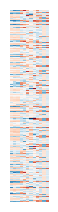

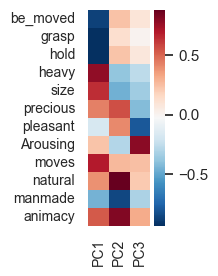

In [35]:
from scipy.stats import pearsonr
# from nilearn import plotting
import seaborn as sns
%matplotlib inline

basedir = r'D:\visual_project\THINGS_project'
outdir_ = pjoin(basedir, r'animacy_analysis\derivatives\2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()
# print(len(ind_1854to720))

sort = [8,6,7,3,11,1,9,10,5,4,0,2]
obj_pro_ = obj_pro[ind_1854to720,:] # (720,12)
obj_pro_sort = obj_pro_[:,sort]
plt.figure(figsize=(0.5,2.5))
ax = sns.heatmap(obj_pro_sort,cmap='RdBu_r',cbar=False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels('')
ax.set_yticklabels('')

obj_pro_pcs_ = scio.loadmat(pjoin(basedir, r'animacy_analysis\derivatives\2_pro_relation', f'obj_pro_pcs.mat'))
obj_pro_pcs__ = obj_pro_pcs_['obj_pro_pcs']
obj_pro_pcs = obj_pro_pcs__[ind_1854to720,:3] # (720,5)
# print(obj_pro_pcs.shape) # (720,5)

corr = []
for i in range(3):
    for j in range(12):
        cor = pearsonr(obj_pro_sort[:,j],obj_pro_pcs[:,i])
        corr.append(cor[0])
corr = np.round(np.array(corr).reshape(3,12).T,2)

x = ['PC1','PC2','PC3']
pro_nm = ['manmade', 'precious', 'animacy', 'heavy', 'natural', 'moves',
           'grasp', 'hold','be_moved', 'pleasant', 'Arousing', 'size']
pro_nm_ = np.array(pro_nm)[sort].tolist()
data={}
for i in range(len(x)):
    data[x[i]] = corr[:,i]
pd_data=pd.DataFrame(data,index=pro_nm_,columns=x)
# print(pd_data)

from matplotlib import font_manager as fm

plt.rcParams.update({'font.size': 10})
rc = {'font.sans-serif': ['Arial']}

plt.figure(figsize=(1,2.8))
sns.set(rc = rc)
sns.heatmap(pd_data,cmap='RdBu_r')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# cbar = ax.collections[0].colorbar
# cbar.ax.tick_params(labelsize=10)

# ref https://zhuanlan.zhihu.com/p/96040773?from_voters_page=true
# ref https://www.cnblogs.com/IvanSSSS/p/12586578.html
# ref https://www.cnblogs.com/IvanSSSS/p/12586578.html

In [12]:
import scipy.io as scio
outdir = pjoin(basedir, r'animacy_analysis\derivatives\obj_pro_analysis_I')
scio.savemat(pjoin(outdir,f'obj_pro_pcs.mat'),{'obj_pro_pcs': obj_pro_pcs[:,:5]})